In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
plt.rcParams.update({'font.size': 22})

In [ ]:
def lb(delta, num_flows, s):
    if s != num_flows:
        return (max(num_flows, s) / s) * delta + (1/s)

    if s == 16:
        if delta == 0.01:
            return 0.075
        elif delta == 0.02:
            return 0.0875
        elif delta == 0.04:
            return 0.1125
        return 0.1625
    elif s == 8:
        if delta == 0.01:
            return 0.1375
        elif delta == 0.02:
            return 0.15
        elif delta == 0.04:
            return 0.175
        return 0.225
    elif s == 4:
        if delta == 0.01:
            return 0.2625
        elif delta == 0.02:
            return 0.275
        elif delta == 0.04:
            return 0.3
        return 0.35
    return (num_flows / s) * delta + (1/s)

In [6]:
def plt_delta_letterver(pct_small = 0.3, num_flows = 16, num_flows_real = None, epsilon = 0.0, plt_num=1, noise=True, n=100, delta_range=[0.04], eclipse=False, ep=False, save=None):
    #plt.figure(figsize=(8, 5))
    marksizeinc = 7
    lineinc = 4
    single_row = {1,3,5,7}
    if plt_num in single_row:
        #fig, axs = plt.subplots(1, 2, figsize=(14, 5))
        fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    else:
        #fig, axs = plt.subplots(2, 2, figsize=(14, 10))
        #fig, axs = plt.subplots(2, 2, figsize=(12, 10.5))
        fig, axs = plt.subplots(1, 2, figsize=(12, 6))
            
    for i, s in enumerate([4, 16]):
        df_filtered = df[(df['noise'] == noise) & (df['n'] == n) & (df['s'] == s) & (df['num_flows'] == num_flows) & (df['pct_small'] == pct_small) & (df['epsilon'] == epsilon)]
        df_filtered2 = df[(df['noise'] == noise) & (df['n'] == n) & (df['s'] == s) & (df['pct_small'] == pct_small) & (df['epsilon'] == epsilon)]
        
        df_filtered3 = df2[(df2['noise'] != noise) & (df2['n'] == n) & (df2['s'] == s) & (df2['num_flows'] == num_flows) & (df2['pct_small'] == pct_small) & (df2['epsilon'] == epsilon)]
        df_filtered4 = df2[(df2['noise'] != noise) & (df2['n'] == n) & (df2['s'] == s) & (df2['pct_small'] == pct_small) & (df2['epsilon'] == epsilon)]

        df_filtered5 = df3[(df3['noise'] == noise) & (df3['n'] == n) & (df3['s'] == s) & (df3['num_flows'] == num_flows) & (df3['pct_small'] == pct_small) & (df3['epsilon'] == epsilon)]
        df_filtered6 = df3[(df3['noise'] == noise) & (df3['n'] == n) & (df3['s'] == s) & (df3['pct_small'] == pct_small) & (df3['epsilon'] == epsilon)]
        #plt.figure(figsize=(5,4))
        #plt.figure(figsize=(8,5))
        #fig, axs = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
        if plt_num in single_row:
            ax = axs[i]
        
        # Plot lines
        if plt_num == 1 or plt_num == 3 or plt_num == 5 or plt_num == 7:
            
            line1, = ax.plot(df_filtered['delta'].unique(), df_filtered['alg2_makespan'], color='red', marker='o', label=f'Spectra', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
            if plt_num == 1:
                line2, = ax.plot(df_filtered['delta'].unique(), df_filtered['less_makespan'], color='blue', marker='^', label=f'Baseline', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                if eclipse:
                    line3, = ax.plot(df_filtered5['delta'].unique(), df_filtered5['alg2_makespan'], color='pink', linestyle='--', label=f'Spectra (Eclipse)', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
            elif plt_num == 3:
                line2, = ax.plot(df_filtered['delta'].unique(), df_filtered['alg1_makespan'], linestyle='--', color='pink', marker='o', label=f'Spectra with no equalization', markersize=3+marksizeinc, linewidth=lineinc)
            elif plt_num == 5:
                line2, = ax.plot(df_filtered['delta'].unique(), df_filtered['less_makespan'], color='blue', marker='^', label=f'Baseline', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                line4, = ax.plot(df_filtered['delta'].unique(), df_filtered['alg2_BFF_makespan'], linestyle='--', color='pink', marker='o', label=f'Spectra (partial reconfig)', markersize=3+marksizeinc, linewidth=lineinc)
                line5, = ax.plot(df_filtered['delta'].unique(), df_filtered['less_BFF_makespan'], linestyle='--', color='purple', marker='^', label=f'Baseline (partial reconfig)', linewidth=max(1, lineinc), markersize=3+marksizeinc)
            elif plt_num == 7:
                line2, = ax.plot(df_filtered['delta'].unique(), df_filtered['less_makespan'], color='blue', marker='^', label=f'Baseline', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                line4, = ax.plot(df_filtered3['delta'].unique(), df_filtered3['alg2_makespan'], linestyle='--', color='pink', marker='o', label=f'Spectra (no noise)', markersize=3+marksizeinc, linewidth=lineinc)
                line5, = ax.plot(df_filtered3['delta'].unique(), df_filtered3['less_makespan'], linestyle='--', color='teal', marker='^', label=f'Baseline (no noise)', linewidth=max(1, lineinc), markersize=3+marksizeinc)
            
            x = [0.01, 0.02, 0.04, 0.08]
            if plt_num == 1:
                pass
                line9, = ax.plot(x, [lb(d, num_flows if num_flows_real is None else num_flows_real, s) for d in x], label="LB", color='green', linestyle=':', linewidth=max(2,lineinc+0.5))
            if i == 0:
                if plt_num == 5 or plt_num == 7:
                    fig.legend(handles=[line1, line4, line2, line5], loc='upper center', ncol=2, frameon=False)
                elif plt_num == 1:
                    #fig.legend(handles=[line1, line2, line3], loc='upper center', ncol=3)
                    if eclipse:
                        fig.legend(handles=[line2, line3, line1, line9], loc='upper center', ncol=4, frameon=False)
                    else:
                        fig.legend(handles=[line2, line1, line9], loc='upper center', ncol=3, frameon=False)
                else:
                    fig.legend(handles=[line1, line2], loc='upper center', ncol=2, frameon=False)
            ax.set_xticks(df_filtered['delta'].unique())
            ax.set_xticks([0.03, 0.05, 0.06, 0.07], minor=True)
            ax.set_xticklabels(['.01', '.02', '.04', '.08'])
            if ep:
                ax.set_xlabel('Reconfiguration delay')
            else:
                ax.set_xlabel('Reconfiguration delay δ')
            ax.tick_params(axis='x', labelsize=22) 
            if i == 0:
                ax.set_ylabel('Makespan')
            #ax.legend()
            if ep:
                ax.grid(True, which='major', color='#E6E6E6', linewidth=0.5)
            else:   
                ax.grid(True, linewidth=0.5, alpha=0.7)
                ax.grid(True, which='minor', linewidth=0.1, alpha=0.2)
            #plt.xscale('log') 
            ax.set_title(f's={s}')
        elif plt_num == 2 or plt_num == 4 or plt_num == 6 or plt_num == 8:
            for j, delta in enumerate(delta_range):
                #ax = axs[j][i]
                ax = axs[i]
                df_filtered = df_filtered2[df_filtered2['delta']==delta].sort_values(by=['num_flows'])
                df_filtered0 = df_filtered4[df_filtered4['delta']==delta].sort_values(by=['num_flows'])

                df_filtered5 = df_filtered6[df_filtered6['delta']==delta].sort_values(by=['num_flows'])
                
                line1, = ax.plot(df_filtered['num_flows'].unique(), df_filtered['alg2_makespan'], color='red', marker='o', label=f'Spectra', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                if plt_num == 2:
                    line2, = ax.plot(df_filtered['num_flows'].unique(), df_filtered['less_makespan'], color='blue', marker='^', label=f'Baseline', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                    if eclipse:
                        line3, = ax.plot(df_filtered5['num_flows'].unique(), df_filtered5['alg2_makespan'], color='pink', linestyle='--', label=f'Spectra (Eclipse)', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                elif plt_num == 4:
                    line2, = ax.plot(df_filtered['num_flows'].unique(), df_filtered['alg1_makespan'], linestyle='--', color='pink', marker='o', label=f'Spectra with no equalization', markersize=3+marksizeinc, linewidth=lineinc)
                elif plt_num == 6:
                    line2, = ax.plot(df_filtered['num_flows'].unique(), df_filtered['less_makespan'], color='blue', marker='^', label=f'Baseline', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                    line4, = ax.plot(df_filtered['num_flows'].unique(), df_filtered['alg2_BFF_makespan'], linestyle='--', color='pink', marker='o', label=f'Spectra (partial reconfig)', markersize=3+marksizeinc, linewidth=lineinc)
                    line5, = ax.plot(df_filtered['num_flows'].unique(), df_filtered['less_BFF_makespan'], linestyle='--', color='purple', marker='^', label=f'Baseline (partial reconfig)', linewidth=max(1, lineinc), markersize=3+marksizeinc)
                elif plt_num == 8:
                    line2, = ax.plot(df_filtered['num_flows'].unique(), df_filtered['less_makespan'], color='blue', marker='^', label=f'Baseline', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                    line4, = ax.plot(df_filtered0['num_flows'].unique(), df_filtered0['alg2_makespan'], linestyle='--', color='pink', marker='o', label=f'Spectra (no noise)', markersize=3+marksizeinc, linewidth=lineinc)
                    line5, = ax.plot(df_filtered0['num_flows'].unique(), df_filtered0['less_makespan'], linestyle='--', color='teal', marker='^', label=f'Baseline (no noise)', linewidth=max(1, lineinc), markersize=3+marksizeinc)
                
                x = list(df_filtered['num_flows'].unique())
                if plt_num == 2:
                    #pass
                    line9, = ax.plot(x, [lb(delta, d, s) for d in x], label="LB", color='green', linestyle=':', linewidth=max(2,lineinc+0.5))
                if i == 0 and j == 0:
                    if plt_num == 6 or plt_num == 8:
                        fig.legend(handles=[line1, line4, line2, line5], loc='upper center', ncol=2, frameon=False)
                    elif plt_num == 2:
                        #fig.legend(handles=[line1, line2, line3], loc='upper center', ncol=3)
                        if eclipse:
                            fig.legend(handles=[line2, line3, line1, line9], loc='upper center', ncol=4, frameon=False)
                        else:
                            fig.legend(handles=[line2, line1, line9], loc='upper center', ncol=3, frameon=False)
                    else:
                        fig.legend(handles=[line1, line2], loc='upper center', ncol=2, frameon=False)
                ax.set_xticks(df_filtered['num_flows'].unique())
                #ax.set_xticks([0.03, 0.05, 0.06, 0.07], minor=True)
                ax.set_xlabel('Number of outgoing flows per port', fontsize=18)
                if i == 0:
                    #ax.set_ylabel(f'Overall Makespan (for δ = {delta})')
                    ax.set_ylabel('Makespan')
                #ax.legend()
                if ep:
                    ax.grid(True, color='#E6E6E6', linewidth=0.5)
                else:
                    ax.grid(True, linewidth=0.5, alpha=0.7)
                #ax.grid(True, which='minor', linewidth=0.1, alpha=0.2)
                #plt.xscale('log') 
                ax.set_title(f's={s}')
    if plt_num not in single_row:
        #fig.text(0.55, 0.48, '(a)', ha='center', va='top')  # for row 1
        #fig.text(0.55, 0.025, '(b)', ha='center', va='top')  # for row 2
        pass
    plt.tight_layout()
    if plt_num in single_row:
        if plt_num >= 5:
            plt.subplots_adjust(top=0.72)
        else:
            plt.subplots_adjust(top=0.79)
    else:
        if plt_num >= 5:
            #plt.subplots_adjust(top=0.84)
            plt.subplots_adjust(top=0.72)
        else:
            #plt.subplots_adjust(top=0.88)
            plt.subplots_adjust(top=0.79)

    """
    if eclipse:
        plt.savefig(
            f"fig-moe-noLB-eclipse-{plt_num}.png",
            dpi=300,           # resolution (dots per inch)
            bbox_inches='tight',  # removes extra whitespace
            #facecolor='white'  # background color
        )
    else:
        plt.savefig(
            f"fig-moe-noLB-{plt_num}.png",
            dpi=300,           # resolution (dots per inch)
            bbox_inches='tight',  # removes extra whitespace
            #facecolor='white'  # background color
        )
    """

    """
    if eclipse:
        plt.savefig(
            f"fig-moe-noLB-eclipse-{plt_num}.eps",
            format="eps",
            bbox_inches='tight',  # removes extra whitespace
            facecolor='white',  # background color
            dpi=600,
            backend='ps'
        )
    else:
        plt.savefig(
            f"fig-moe-noLB-{plt_num}.eps",
            format="eps",
            bbox_inches='tight',  # removes extra whitespace
            facecolor='white',  # background color
            dpi=600,
            backend='ps'
        )
    """



    """
    if ep:
        if eclipse:
            plt.savefig(
                f"fig-moe-LB-eclipse-{plt_num}.eps",
                format="eps",
                bbox_inches='tight',  # removes extra whitespace
                facecolor='white',  # background color
                dpi=600,
                backend='ps'
            )
        else:
            plt.savefig(
                f"fig-moe-LB-{plt_num}.eps",
                format="eps",
                bbox_inches='tight',  # removes extra whitespace
                facecolor='white',  # background color
                dpi=600,
                backend='ps'
            )
    else:
        if eclipse:
            plt.savefig(
                f"fig-syn-LB-eclipse-{plt_num}.png",
                dpi=300,           # resolution (dots per inch)
                bbox_inches='tight',  # removes extra whitespace
                #facecolor='white'  # background color
            )
        else:
            plt.savefig(
                f"fig-syn-LB-{plt_num}.png",
                dpi=300,           # resolution (dots per inch)
                bbox_inches='tight',  # removes extra whitespace
                #facecolor='white'  # background color
            )
    """

    if save is not None:
        if ep:
            plt.savefig(
                save,#f"fig-moe-LB-eclipse-{plt_num}.eps",
                format="eps",
                bbox_inches='tight',  # removes extra whitespace
                facecolor='white',  # background color
                dpi=600,
                backend='ps'
            )
        else:
            plt.savefig(
                save,#f"fig-syn-LB-eclipse-{plt_num}.png",
                dpi=300,           # resolution (dots per inch)
                bbox_inches='tight',  # removes extra whitespace
                #facecolor='white'  # background color
            )
    
    plt.show()


In [7]:
def plt_delta_oldaiver(pct_small = 0.3, num_flows = 16, epsilon = 0.0, plt_num=1, noise=False, n=100, delta_range=[0.02, 0.04], eclipse=False, qwen=False, iters=[1,2,3,4,5,6], save=None):
    marksizeinc = 7
    lineinc = 4
    
    if qwen:
        iters=[10]
    for ai in iters:
        #plt.figure(figsize=(8, 5))
        title = ""
        title2 = ""
        if ai == 1:
            title = "MoE"
            title2 = "MoE8"
            n=8
        elif ai == 2:
            title = "MoE"
            title2 = "MoE64"
            n=64
        elif ai == 3:
            title = "MoE"
            title2 = "MoE128"
            n=128
        elif ai == 4:
            title = "GPT"
            title2 = "GPT32"
            n=32
        elif ai == 5:
            title = "GPT"
            title2 = "GPT64"
            n=64
        elif ai == 6:
            title = "GPT"
            title2 = "GPT128"
            n=128
        elif ai == 10:
            title = "Qwen"
            title2 = "Qwen"
            n=64
        
        if ai in {1,2,3}:
            num_flows = 7
        else:
            num_flows = 4

        if ai == 10:
            num_flows = 64
        
        single_row = {1,3,5,7,9}
        if plt_num in single_row:
            #fig, axs = plt.subplots(1, 2, figsize=(14, 5))
            fig, axs = plt.subplots(1, 2, figsize=(12, 6))
        else:
            #fig, axs = plt.subplots(2, 2, figsize=(14, 10))
            fig, axs = plt.subplots(2, 2, figsize=(12, 10.5))
                
        for i, s in enumerate([4, 16]):
            df_filtered = df[(df['noise'] == noise) & (df['s'] == s) & (df['pct_small'] == pct_small) & (df['epsilon'] == epsilon) & (df['ai'] == ai)]
            df_filtered2 = df[(df['noise'] == noise) & (df['s'] == s) & (df['pct_small'] == pct_small) & (df['epsilon'] == epsilon) & (df['ai'] == ai)]

            df_filtered3 = df2[(df2['noise'] == noise) & (df2['s'] == s) & (df2['pct_small'] == pct_small) & (df2['epsilon'] == epsilon) & (df2['ai'] == ai)]

            df_filtered4 = None
            df_filtered5 = None
            if plt_num == 5:
                df_filtered4 = df3[(df3['noise'] == noise) & (df3['s'] == s) & (df3['pct_small'] == pct_small) & (df3['epsilon'] == epsilon) & (df3['ai'] == ai)]
            elif plt_num == 9:
                df_filtered4 = df3[(df3['noise'] == noise) & (df3['s'] == s) & (df3['pct_small'] == pct_small) & (df3['epsilon'] == epsilon) & (df3['ai'] == ai) & (df3['decomp_num'] == 1)]
                df_filtered5 = df3[(df3['noise'] == noise) & (df3['s'] == s) & (df3['pct_small'] == pct_small) & (df3['epsilon'] == epsilon) & (df3['ai'] == ai) & (df3['decomp_num'] == 6)]
            #df_filtered3 = df2[(df2['noise'] != noise) & (df2['n'] == n) & (df2['s'] == s) & (df2['num_flows'] == num_flows) & (df2['pct_small'] == pct_small) & (df2['epsilon'] == epsilon)]
            #df_filtered4 = df2[(df2['noise'] != noise) & (df2['n'] == n) & (df2['s'] == s) & (df2['pct_small'] == pct_small) & (df2['epsilon'] == epsilon)]
            #plt.figure(figsize=(5,4))
            #plt.figure(figsize=(8,5))
            #fig, axs = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
            if plt_num in single_row:
                ax = axs[i]
            
            # Plot lines
            if plt_num == 1 or plt_num == 3 or plt_num == 5 or plt_num == 7 or plt_num == 9:
                if plt_num != 9:
                    line1, = ax.plot(df_filtered['delta'].unique(), df_filtered['alg2_makespan'], color='red', marker='o', label=f'Spectra', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                
                if plt_num == 1:
                    line2, = ax.plot(df_filtered['delta'].unique(), df_filtered['less_makespan'], color='blue', marker='^', label=f'Baseline', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                    if eclipse:
                        line4, = ax.plot(df_filtered3['delta'].unique(), df_filtered3['alg2_makespan'], color='pink', linestyle='--', label=f'Spectra (Eclipse)', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                elif plt_num == 3:
                    line2, = ax.plot(df_filtered['delta'].unique(), df_filtered['alg1_makespan'], linestyle='-.', color='magenta', marker='o', label=f'Spectra with no equalization', markersize=3+marksizeinc, linewidth=lineinc)
                    if eclipse:
                        line4, = ax.plot(df_filtered3['delta'].unique(), df_filtered3['alg1_makespan'], linestyle='--', color='teal', marker='o', label=f'Spectra (Eclipse) with no equalization', markersize=3+marksizeinc, linewidth=lineinc-1)
                        line3, = ax.plot(df_filtered3['delta'].unique(), df_filtered3['alg2_makespan'], linestyle=':', color='blue', marker='o', label=f'Spectra (Eclipse)', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                elif plt_num == 5:
                    line2, = ax.plot(df_filtered['delta'].unique(), df_filtered['less_makespan'], color='blue', marker='^', label=f'Baseline', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                    line4, = ax.plot(df_filtered['delta'].unique(), df_filtered['alg2_BFF_makespan'], linestyle='--', color='pink', marker='o', label=f'Spectra (partial reconfig)', markersize=3+marksizeinc, linewidth=lineinc)
                    line5, = ax.plot(df_filtered['delta'].unique(), df_filtered['less_BFF_makespan'], linestyle='--', color='purple', marker='^', label=f'Baseline (partial reconfig)', linewidth=max(1, lineinc), markersize=3+marksizeinc)
                    if eclipse:
                        line6, = ax.plot(df_filtered4['delta'].unique(), df_filtered4['alg2_makespan'], linestyle=':', color='green', marker='o', label=f'Spectra (Eclipse)', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc-1)
                        line7, = ax.plot(df_filtered4['delta'].unique(), df_filtered4['alg2_BFF_makespan'], linestyle='--', color='teal', marker='o', label=f'Spectra (Eclipse) (partial reconfig)', markersize=3+marksizeinc, linewidth=lineinc-1)
                elif plt_num == 7:
                    line2, = ax.plot(df_filtered['delta'].unique(), df_filtered['less_makespan'], color='blue', marker='^', label=f'Baseline', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                    line4, = ax.plot(df_filtered3['delta'].unique(), df_filtered3['alg2_makespan'], linestyle='--', color='pink', marker='o', label=f'Spectra (no noise)', markersize=3+marksizeinc, linewidth=lineinc)
                    line5, = ax.plot(df_filtered3['delta'].unique(), df_filtered3['less_makespan'], linestyle='--', color='teal', marker='^', label=f'Baseline (no noise)', linewidth=max(1, lineinc), markersize=3+marksizeinc)
                elif plt_num == 9:
                    line1, = ax.plot(df_filtered['delta'].unique(), df_filtered['alg2_makespan'], color='gray', marker='o', label=f'Spectra', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                    line2, = ax.plot(df_filtered4['delta'].unique(), df_filtered4['alg2_makespan'], color='red', marker='o', label=f'Spectra with more noise', markersize=3+marksizeinc, linewidth=lineinc)
                    if eclipse:
                        line3, = ax.plot(df_filtered3['delta'].unique(), df_filtered3['alg2_makespan'], linestyle='--', color='gray', marker='o', label=f'Spectra (Eclipse)', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                        line4, = ax.plot(df_filtered5['delta'].unique(), df_filtered5['alg2_makespan'], linestyle='--', color='pink', marker='o', label=f'Spectra (Eclipse) with more noise', markersize=3+marksizeinc, linewidth=lineinc-1)
                        
                
                x = [0.01, 0.02, 0.04, 0.08]
                if plt_num == 1:
                    line3, = ax.plot(x, [lb(d, num_flows, s) for d in x], label="LB", color='green', linestyle=':', linewidth=max(2,lineinc+0.5))
                if i == 0:
                    if plt_num == 5:
                        if eclipse:
                            #fig.legend(handles=[line1, line4, line6, line7, line2, line5], loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.93), frameon=False)
                            fig.legend(handles=[line1, line6, line2, line4, line7, line5], loc='upper center', ncol=2, bbox_to_anchor=(0.55, 1.0), frameon=False)
                        else:
                            fig.legend(handles=[line1, line4, line2, line5], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.93), frameon=False)
                    elif plt_num == 7:
                        fig.legend(handles=[line1, line4, line2, line5], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.93), frameon=False)
                    elif plt_num == 1:
                        if eclipse:
                            fig.legend(handles=[line1, line4, line2, line3], loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.93), frameon=False)
                        else:
                            fig.legend(handles=[line1, line2, line3], loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.93), frameon=False)
                    elif plt_num == 9:
                        if eclipse:
                            fig.legend(handles=[line1, line2, line3, line4], loc='upper center', ncol=2, bbox_to_anchor=(0.55, 1.0), frameon=False)
                        else:
                            fig.legend(handles=[line1, line2], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.93), frameon=False)
                    else:
                        if eclipse:
                            fig.legend(handles=[line1, line2, line3, line4], loc='upper center', ncol=2, bbox_to_anchor=(0.55, 1.0), frameon=False)
                        else:
                            fig.legend(handles=[line1, line2], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.93), frameon=False)
                ax.set_xticks(df_filtered['delta'].unique())
                ax.set_xticks([0.03, 0.05, 0.06, 0.07], minor=True)
                ax.set_xticklabels(['.01', '.02', '.04', '.08'])
                ax.set_xlabel('Reconfiguration delay δ')
                ax.tick_params(axis='x', labelsize=22) 
                if i == 0:
                    ax.set_ylabel('Makespan')
                #ax.legend()
                ax.grid(True, linewidth=0.5, alpha=0.7)
                ax.grid(True, which='minor', linewidth=0.1, alpha=0.2)
                #plt.xscale('log') 
                ax.set_title(f's={s}')
            elif plt_num == 2 or plt_num == 4 or plt_num == 6 or plt_num == 8:
                for j, delta in enumerate(delta_range):
                    ax = axs[j][i]
                    df_filtered = df_filtered2[df_filtered2['delta']==delta]
                    df_filtered0 = df_filtered4[df_filtered4['delta']==delta]
                    
                    line1, = ax.plot(df_filtered['num_flows'].unique(), df_filtered['alg2_makespan'], color='red', marker='o', label=f'Spectra', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                    if plt_num == 2:
                        line2, = ax.plot(df_filtered['num_flows'].unique(), df_filtered['less_makespan'], color='blue', marker='^', label=f'Baseline', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                    elif plt_num == 4:
                        line2, = ax.plot(df_filtered['num_flows'].unique(), df_filtered['alg1_makespan'], linestyle='--', color='pink', marker='o', label=f'Spectra with no equalization', markersize=3+marksizeinc, linewidth=lineinc)
                    elif plt_num == 6:
                        line2, = ax.plot(df_filtered['num_flows'].unique(), df_filtered['less_makespan'], color='blue', marker='^', label=f'Baseline', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                        line4, = ax.plot(df_filtered['num_flows'].unique(), df_filtered['alg2_BFF_makespan'], linestyle='--', color='pink', marker='o', label=f'Spectra (partial reconfig)', markersize=3+marksizeinc, linewidth=lineinc)
                        line5, = ax.plot(df_filtered['num_flows'].unique(), df_filtered['less_BFF_makespan'], linestyle='--', color='teal', marker='^', label=f'Baseline (partial reconfig)', linewidth=max(1, lineinc), markersize=3+marksizeinc)
                    elif plt_num == 8:
                        line2, = ax.plot(df_filtered['num_flows'].unique(), df_filtered['less_makespan'], color='blue', marker='^', label=f'Baseline', markersize=7+marksizeinc, markerfacecolor='none', linewidth=lineinc)
                        line4, = ax.plot(df_filtered0['num_flows'].unique(), df_filtered0['alg2_makespan'], linestyle='--', color='pink', marker='o', label=f'Spectra (no noise)', markersize=3+marksizeinc, linewidth=lineinc)
                        line5, = ax.plot(df_filtered0['num_flows'].unique(), df_filtered0['less_makespan'], linestyle='--', color='teal', marker='^', label=f'Baseline (no noise)', linewidth=max(1, lineinc), markersize=3+marksizeinc)
                    
                    x = list(df_filtered['num_flows'].unique())
                    if plt_num == 2:
                        #line3, = ax.plot(x, [(d / s) * delta + (1 / s) for d in x], label="LB", color='green', linestyle=':')
                        line3, = ax.plot(x, [lb(delta, d, s) for d in x], label="LB", color='green', linestyle=':', linewidth=max(2,lineinc+0.5))
                    if i == 0 and j == 0:
                        if plt_num == 6 or plt_num == 8:
                            fig.legend(handles=[line1, line4, line2, line5], loc='upper center', ncol=4, frameon=False)
                        elif plt_num == 2:
                            fig.legend(handles=[line1, line2, line3], loc='upper center', ncol=3, frameon=False)
                        else:
                            fig.legend(handles=[line1, line2], loc='upper center', ncol=2, frameon=False)
                    ax.set_xticks(df_filtered['num_flows'].unique())
                    #ax.set_xticks([0.03, 0.05, 0.06, 0.07], minor=True)
                    ax.set_xlabel('Number of flows per node')
                    if i == 0:
                        ax.set_ylabel(f'Overall Makespan (for δ = {delta})')
                    #ax.legend()
                    ax.grid(True, linewidth=0.5, alpha=0.7)
                    #ax.grid(True, which='minor', linewidth=0.1, alpha=0.2)
                    #plt.xscale('log') 
                    ax.set_title(f's={s}')
        
        plt.tight_layout()
        #fig.suptitle(title)
        if plt_num in single_row:
            if plt_num >= 5:
                plt.subplots_adjust(top=0.66)
            else:
                plt.subplots_adjust(top=0.73)
        else:
            plt.subplots_adjust(top=0.93)

        if save is not None:
            plt.savefig(
                f"GOLDEN/ai{plt_num}_{title2}.png",
                dpi=300,           # resolution (dots per inch)
                bbox_inches='tight',  # removes extra whitespace
                #facecolor='white'  # background color
            )
        
        plt.show()


In [9]:
df

,s,delta,epsilon,noise,num_flows,pct_small,birk_runtime,birk_runtime_std,birk_less_runtime,birk_less_runtime_std,...,n,alg1_BFF_nz,alg2_BFF_nz,alg1_BFF_delta0_nz,alg2_BFF_delta0_nz,less_nz,decomp_num,sorted,lesspct,lessBFFpct
0,4,0.01,0.0,True,16,0.3,1.27560,0.053887,2.26078,0.144486,...,20,0,0,0,0,343,13,False,85.340302,0.0
1,4,0.02,0.0,True,16,0.3,1.97664,1.390050,2.16746,0.121263,...,20,0,0,0,0,344,13,False,84.174301,0.0
2,4,0.04,0.0,True,16,0.3,2.21608,1.647115,2.31150,0.121428,...,20,0,0,0,0,343,13,False,84.684801,0.0
3,4,0.08,0.0,True,16,0.3,1.89888,1.272962,2.20806,0.096003,...,20,0,0,0,0,342,13,False,85.027752,0.0
4,16,0.01,0.0,True,16,0.3,1.44372,0.054492,6.48488,1.750905,...,20,0,0,0,0,787,13,False,92.914708,0.0
5,16,0.02,0.0,True,16,0.3,1.34444,0.094342,6.10598,1.380611,...,20,0,0,0,0,777,13,False,94.530377,0.0
6,16,0.04,0.0,True,16,0.3,1.41812,0.079017,7.59938,2.189368,...,20,0,0,0,0,779,13,False,91.632008,0.0
7,16,0.08,0.0,True,16,0.3,2.23136,1.621671,9.52822,7.768687,...,20,0,0,0,0,774,13,False,81.541513,0.0


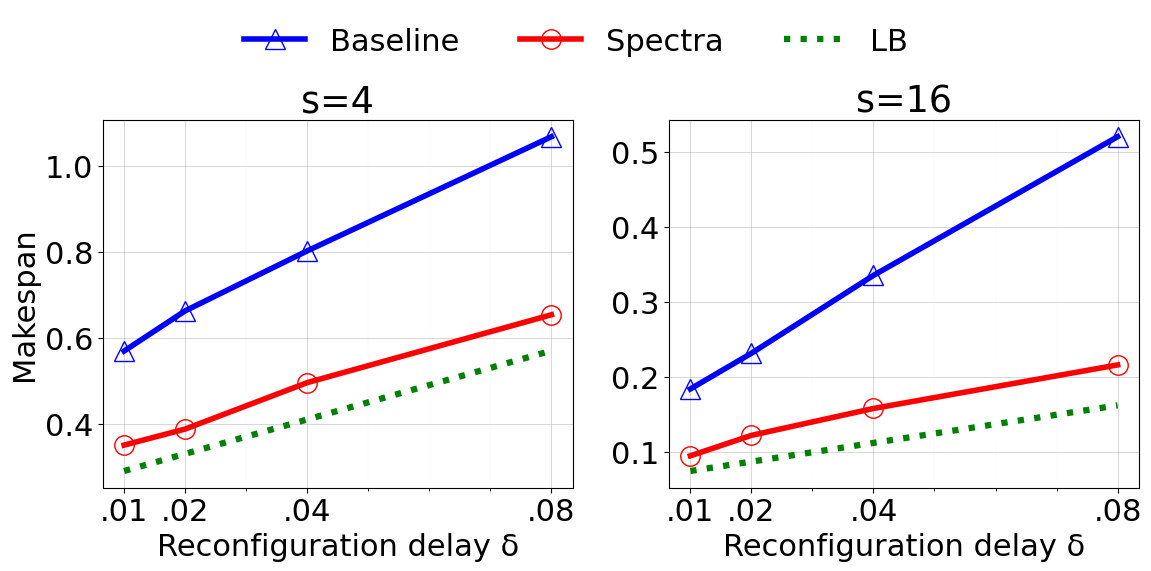

In [10]:
out_filename = "test.csv"

df = pd.read_csv(out_filename)
df2 = pd.read_csv(out_filename)
df3 = pd.read_csv(out_filename)

plt_delta_letterver(pct_small = 0.3, num_flows = 16, epsilon = 0.0, plt_num=1, noise=True, n=20, eclipse=False, ep=False, save=None)